# Lab 4: Modelos Formales

En los modelos formales, no hay un mecanismo de generación de spikes. La ecuación que describe la dinámica subumbral es de la forma

$$\tau \dot{V} = f(V) + RI(t)$$

junto con el mecanismo de disparo:

$$
t^f: V(t^f) = V_{th} \\
\lim_{\delta \to 0} V(t^f + \delta) = V_{reset}
$$

A continuación veremos el comportamiento de algunos modelos formales

## Ejercicio 1: Leaky Integrate and Fire

El modelo LIF es de la forma

$$
\tau \dot{V} = -(V - V_{rest}) + R I(t)
$$

Asuma que $V_{th} = -55.0$mV, $V_{reset}=V_{rest}=-75.0$mV, $\tau_m = 10.0$, $R=0.1$, $V(0)=-75.0$. Para todos los protocolos use un método de Euler con $dt = 0.1$

1. Simule una neurona LIF usando un protocolo de corriente $I = 100$pA entre $t = [50, 150]ms$.
2. Simule una neurona LIF usando un protocolo de corriente $I = 300$pA entre $t = [50, 150]ms$.
3. Simule la neurona LIF usando $I(t) = A(1 + \sin(\omega t))$, con $\omega = 0.5$ y $A = 200$pA

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros:

Vth = -55
Vrest = -75
Tm = 10
R = 0.1

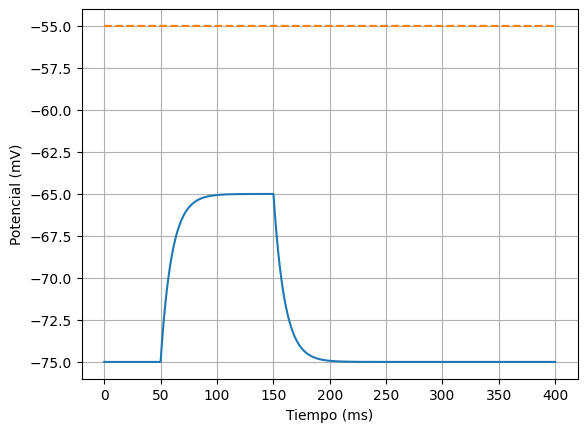

In [4]:
# Parte (a):
def I(t):
  return 100 if 50 <= t <= 150 else 0

h = 0.1
t = np.arange(0, 400, h)
V = np.zeros(t.shape)
V[0] = -75

for n in range(len(t)-1):
    V[n+1] = V[n] + h * (-(V[n]-Vrest)+R*I(t[n]))/Tm
    if V[n+1] >= Vth:
        V[n+1] = Vrest

plt.plot(t, V)
plt.plot(t, np.ones_like(t)*Vth,"--")
plt.xlabel('Tiempo (ms)')
plt.ylabel('Potencial (mV)')
plt.grid()
plt.show()

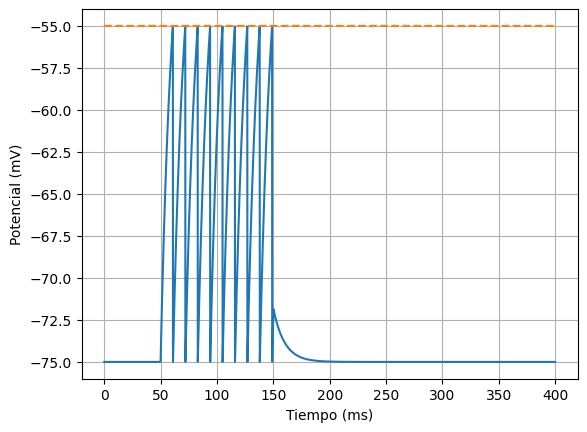

In [5]:
# Parte (b):
def I(t):
  return 300 if 50 <= t <= 150 else 0

h = 0.1
t = np.arange(0, 400, h)
V = np.zeros(t.shape)
V[0] = -75

for n in range(len(t)-1):
    V[n+1] = V[n] + h * (-(V[n]-Vrest)+R*I(t[n]))/Tm
    if V[n+1] >= Vth:
        V[n+1] = Vrest

plt.plot(t, V)
plt.plot(t, np.ones_like(t)*Vth,"--")
plt.xlabel('Tiempo (ms)')
plt.ylabel('Potencial (mV)')
plt.grid()
plt.show()

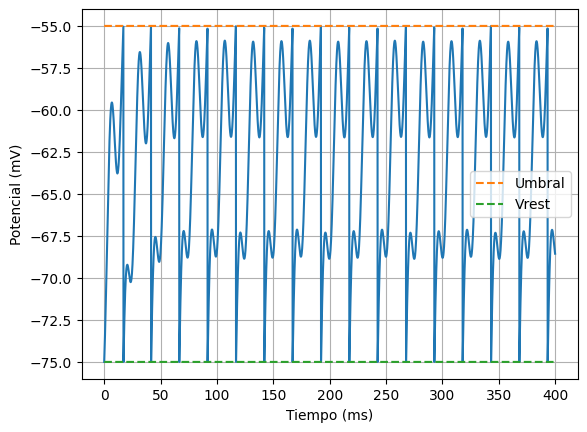

In [6]:
# Parte (c):
def I(t):
  A = 200
  omega = 0.5
  return A*(1+np.sin(omega*t))

h = 0.1
t = np.arange(0, 400, h)
V = np.zeros(t.shape)
V[0] = -75

for n in range(len(t)-1):
    V[n+1] = V[n] + h * (-(V[n]-Vrest)+R*I(t[n]))/Tm
    if V[n+1] >= Vth:
        V[n+1] = Vrest

plt.plot(t, V)
plt.plot(t, np.ones_like(t)*Vth,"--",label="Umbral")
plt.xlabel('Tiempo (ms)')
plt.ylabel('Potencial (mV)')
plt.plot(t,np.ones_like(t)*Vrest,"--",label="Vrest")
plt.grid()
plt.legend()
plt.show()

## Ejercicio 2:

Compute la curva f-I y compare sus resultados con lo esperado teóricamente.

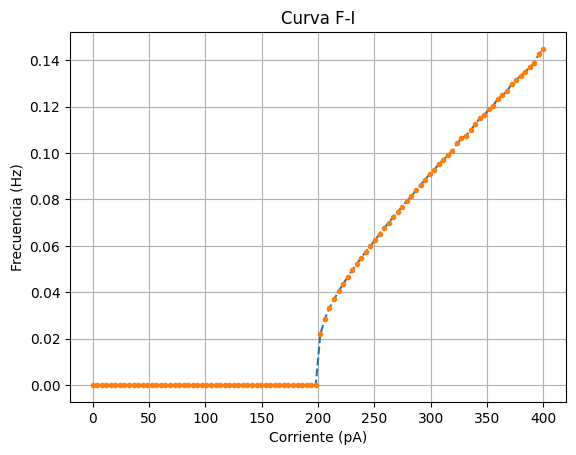

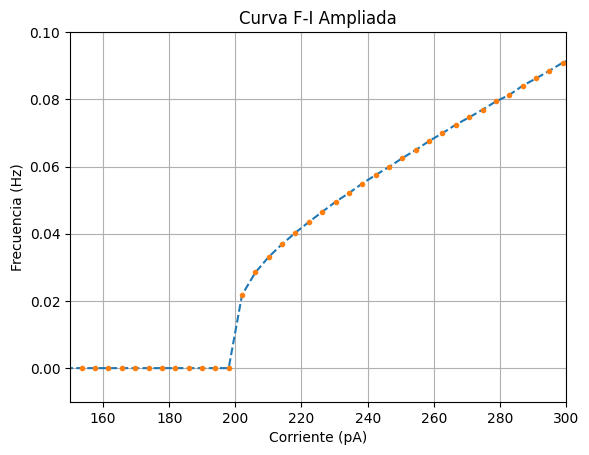

In [58]:
import numpy as np
import matplotlib.pyplot as plt

I = np.linspace(0,400,100) # Corrientes externa.
Frec_disparo = np.array([])

# Parámetros:
Vth = -55
Vrest = -75
Tm = 10
R = 0.1

# Hago estudio para cada corriente.
for Iext in I:
  t = np.arange(0, 400, h) # Tiempo de cada estudio.
  V = np.zeros_like(t)
  V[0] = -75

  tspike = np.array([])
  # Calculo Pot. Memb. V.
  for n in range(len(t)-1):
    V[n+1] = V[n] + h * (-(V[n]-Vrest)+R*Iext)/Tm
    if V[n+1] >= Vth:
        V[n+1] = Vrest
        tspike = np.append(tspike, t[n])

  # Calculamos la frec.
  if len(tspike) < 2:
    # No datos suficientes.
    Frec_disparo = np.append(Frec_disparo, 0)
  else:
    T = np.mean(np.diff(tspike))
    Frec_disparo = np.append(Frec_disparo, 1/T)


plt.plot(I,Frec_disparo,"--")
plt.plot(I,Frec_disparo,".")
plt.xlabel('Corriente (pA)')
plt.ylabel('Frecuencia (Hz)')
plt.title('Curva F-I')
plt.grid()
plt.show()

plt.plot(I, Frec_disparo,"--")
plt.plot(I,Frec_disparo,".")
plt.xlabel('Corriente (pA)')
plt.ylabel('Frecuencia (Hz)')
plt.title('Curva F-I Ampliada')
plt.grid()
plt.xlim(150,300)
plt.ylim(-0.01,0.1)
plt.show()

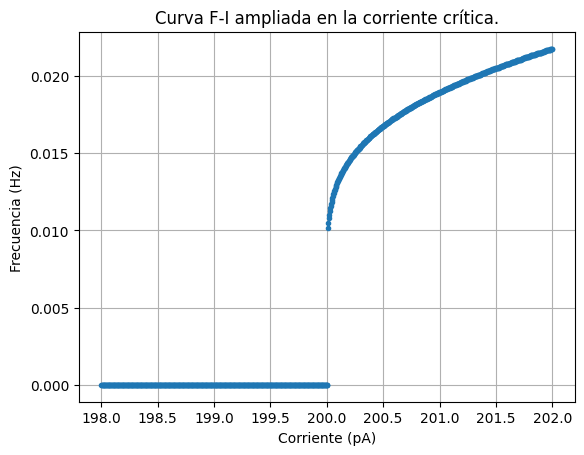

In [79]:
I = np.linspace(198,202,1000) # Corrientes externa.
Frec_disparo = np.array([])

# Parámetros:
Vth = -55
Vrest = -75
Tm = 10
R = 0.1

# Hago estudio para cada corriente.
for Iext in I:
  t = np.arange(0, 200, h) # Tiempo de cada estudio.
  V = np.zeros_like(t)
  V[0] = -75

  tspike = np.array([])
  # Calculo Pot. Memb. V.
  for n in range(len(t)-1):
    V[n+1] = V[n] + h * (-(V[n]-Vrest)+R*Iext)/Tm
    if V[n+1] >= Vth:
        V[n+1] = Vrest
        tspike = np.append(tspike, t[n])

  # Calculamos la frec.
  if len(tspike) < 2:
    # No datos suficientes.
    Frec_disparo = np.append(Frec_disparo, 0)
  else:
    T = np.mean(np.diff(tspike))
    Frec_disparo = np.append(Frec_disparo, 1/T)


plt.plot(I,Frec_disparo,".")
plt.xlabel('Corriente (pA)')
plt.ylabel('Frecuencia (Hz)')
plt.title('Curva F-I ampliada en la corriente crítica.')
plt.grid()
plt.show()

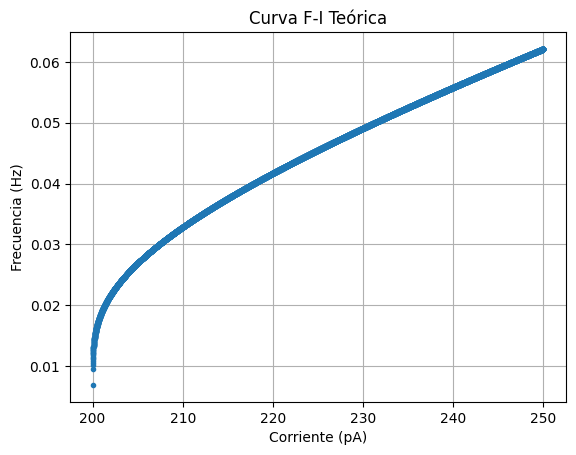

In [64]:
# I teoríca.
I_critico = (Vth-Vrest)/R+0.0001 # Infinitesimalmente cerca al I critico. Antes de ese I los f son aproximadamente 0.
f = np.array([])

I_teorica = np.linspace(I_critico,250,10000)
for I0 in I_teorica:
  valor = 1/(-Tm*np.log(1-(Vth-Vrest)/(R*I0)))
  f = np.append(f,valor)

plt.plot(I_teorica,f,".")
plt.xlabel('Corriente (pA)')
plt.ylabel('Frecuencia (Hz)')
plt.title('Curva F-I Teórica')
plt.grid()
plt.show()

Como vemos, al tratarse de una simulación de una función logarítmica que se indetermina en los puntos cercanos antes de comenzar a disparar, la aproximación nos hace pensar que la neurona es de tipo II, pero notemos que si hacemos la solución teorica con unidades que nos ayuden a aproximar y ver que sucede en el infinito, vemos que la neurona comienza a disparar con pulsos pequeños y la frecuencia de disparo va creciendo controladamente, por lo cual, a pesar de tener dificultades con ver la curva f-I precisa, podemos concluir que se modela una neurona de tipo I.

## Ejercicio 3:

En ocasiones puede ser útil hacer que su código detecte automáticamente cuándo una condición determinada se cumple. Por ejemplo que su código pueda detectar automáticamente cuándo el potencial de membrana pasa por $V_{th}$ para así dar el tratamiento adecuado a su problema. -En nuestro caso resetear el potencial de membrana a $V_{rest}$-.

Para ello es útil usar una rutina automática de detección de eventos. solve_ivp tiene la opción **events** que trata precisamente este tipo de problemas. Intente leer la documentación sobre cómo implementar la rutina de detección de eventos en su problema y simule una neurona LIF sujeta a una corriente constante $I = 300$pA.

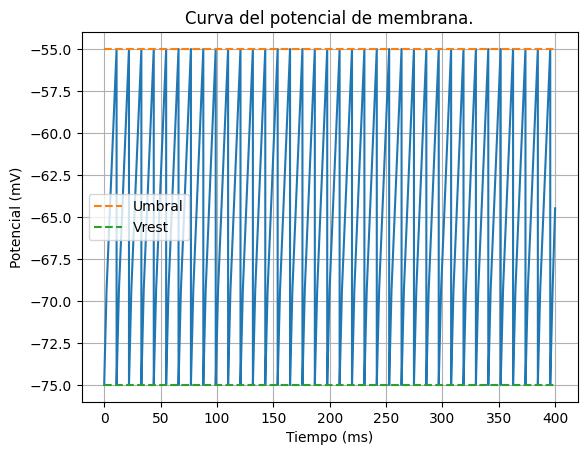

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Parámetros:
Vth = -55
Vrest = -75
Tm = 10
R = 0.1
I = 300

# Encontrar envento.
def umbral_evento(t,X,Vth,Vrest,R,I,Tm):
  V = X[0]
  return V - Vth
# Parar el solveIVP para volver V a Vrest.
umbral_evento.terminal = True

# Función para el SolveIVP.
def neurona_lif(t,X,Vth,Vrest,R,I,Tm):
  V = X[0]
  return (-(V - Vrest) + R*I)/Tm


t_span = [0, 400]
V0=-75
t = np.array([0])
V = np.array([V0])
t_event = np.array([])

while t_span[0] < t_span[1]:
  sol = solve_ivp(neurona_lif, t_span, [V0], args=(Vth,Vrest,R,I,Tm,), events=umbral_evento)
  # Almacenar los resultados
  t = np.concatenate((t, sol.t[1:]))
  V = np.concatenate((V, sol.y[0][1:]))

  # Si se detectó un evento, resetear el potencial
  if sol.status == 1:  # Evento detectado
    t_event = np.append(t_event, sol.t_events[0][0])
    V0 = Vrest
    t = np.append(t,sol.t_events[0][0])
    V = np.append(V,Vrest)
    t_span[0] = sol.t_events[0][0]
  else:
    t_span[0] = t_span[1]
plt.plot(t, V)
plt.plot(t, np.ones_like(t)*Vth,"--",label="Umbral")
plt.plot(t,np.ones_like(t)*Vrest,"--",label="Vrest")
plt.legend()
plt.xlabel('Tiempo (ms)')
plt.ylabel('Potencial (mV)')
plt.title('Curva del potencial de membrana.')
plt.grid()
plt.show()

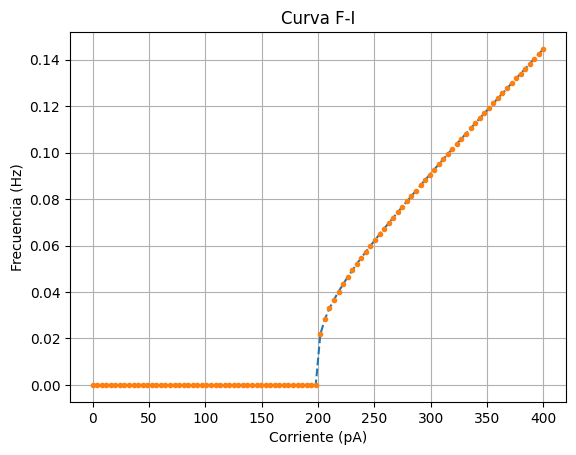

In [ ]:
# Curva F-I para comparar implementación.

Is = np.linspace(0,400,100)
Frec = np.array([])

for I in Is:

  # Parámetros:
  Vth = -55
  Vrest = -75
  Tm = 10
  R = 0.1

  # Encontrar envento.
  def umbral_evento(t,X,Vth,Vrest,R,I,Tm):
    V = X[0]
    return V - Vth
  # Parar el solveIVP para volver V a Vrest.
  umbral_evento.terminal = True

  # Función para el SolveIVP.
  def neurona_lif(t,X,Vth,Vrest,R,I,Tm):
    V = X[0]
    return (-(V - Vrest) + R*I)/Tm


  t_span = [0, 400]
  V0=-75
  t = np.array([0])
  V = np.array([V0])
  t_event = np.array([])

  while t_span[0] < t_span[1]:
    sol = solve_ivp(neurona_lif, t_span, [V0], args=(Vth,Vrest,R,I,Tm,), events=umbral_evento)
    # Almacenar los resultados
    t = np.concatenate((t, sol.t[1:]))
    V = np.concatenate((V, sol.y[0][1:]))

    # Si se detectó un evento, resetear el potencial
    if sol.status == 1:  # Evento detectado
      t_event = np.append(t_event, sol.t_events[0][0])
      V0 = Vrest
      t = np.append(t,sol.t_events[0][0])
      V = np.append(V,Vrest)
      t_span[0] = sol.t_events[0][0]
    else:
      t_span[0] = t_span[1]
  if len(t_event) < 2:
    Frec = np.append(Frec, 0)
  else:
    T = np.mean(np.diff(t_event))
    Frec = np.append(Frec, 1/T)

plt.plot(Is, Frec,"--")
plt.plot(Is,Frec,".")
plt.xlabel('Corriente (pA)')
plt.ylabel('Frecuencia (Hz)')
plt.title('Curva F-I')
plt.grid()
plt.show()
